# 01 - EDA de accidentes

Análisis exploratorio sobre `data/processed/accidentes_2023.csv` y
`accidentes_2024.csv` — ya limpios y anonimizados (ver
`notebooks/00_inventario_fuentes.ipynb` y `reports/diccionario_datos.md`).
Este notebook solo importa y muestra: la lógica vive en `src/`.

Hay 3 fuentes adicionales en `data/processed/` (`accidentes_historico_2012_2022.csv`,
`accidentes_2025_2026.csv`, `incidentes_2025_2026.csv`) con esquemas de
columnas distintos — se exploran por separado al final de este notebook en
vez de forzarlas al mismo `df` combinado de 2023-2024.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.config import FIGURES_DIR, PROCESSED_DIR

sns.set_theme()

cols_fecha = ["fecha_evento", "fecha_ingreso_labores"]
df23 = pd.read_csv(PROCESSED_DIR / "accidentes_2023.csv", parse_dates=cols_fecha)
df24 = pd.read_csv(PROCESSED_DIR / "accidentes_2024.csv", parse_dates=cols_fecha)

# Combinado solo para las columnas comunes a ambos años (EDA general).
# Para columnas exclusivas de un año, trabajar df23/df24 por separado.
df = pd.concat([df23, df24], ignore_index=True)
df.shape

(388, 47)

## Vista general

In [2]:
df.dtypes

item                               float64
nro_rom                                str
pais                                   str
sociedad                               str
predio                                 str
planta                                 str
direccion                              str
area                                   str
fecha_evento                datetime64[us]
semana                             float64
dia                                float64
mes                                float64
anio                               float64
hora                                   str
turno                                  str
tipo_trabajador                        str
empresa                                str
sexo                                   str
edad_anios                         float64
puesto_trabajo                         str
fecha_ingreso_labores       datetime64[us]
descripcion_accidente                  str
tipo_contacto                          str
parte_cuerp

In [3]:
df.describe(include="number")

,item,semana,dia,mes,anio,edad_anios,dias_dm,dias_dm_total_indicador,tiempo_experiencia_meses,fuente_archivo,poblacion
count,275.000000,386.000000,297.000000,298.000000,297.000000,270.000000,352.000000,329.000000,192.000000,388.000000,264.0
mean,130.578182,25.906736,16.589226,6.442953,2023.942761,35.477778,9.761364,12.045593,58.161146,2023.724227,0.0
std,79.323993,14.798091,8.612900,3.317909,0.232691,10.956380,24.703020,55.586790,90.647431,0.447480,0.0
min,1.000000,1.000000,1.000000,1.000000,2023.000000,18.000000,0.000000,0.000000,0.000000,2023.000000,0.0
25%,61.500000,13.000000,9.000000,4.000000,2024.000000,26.000000,0.000000,0.000000,2.000000,2023.000000,0.0
50%,130.000000,27.000000,17.000000,7.000000,2024.000000,33.500000,0.000000,0.000000,10.000000,2024.000000,0.0
75%,198.500000,38.000000,23.000000,9.000000,2024.000000,43.000000,9.000000,8.000000,72.000000,2024.000000,0.0
max,270.000000,52.000000,31.000000,12.000000,2024.000000,62.000000,180.000000,904.000000,348.000000,2024.000000,0.0


## Accidentes por mes

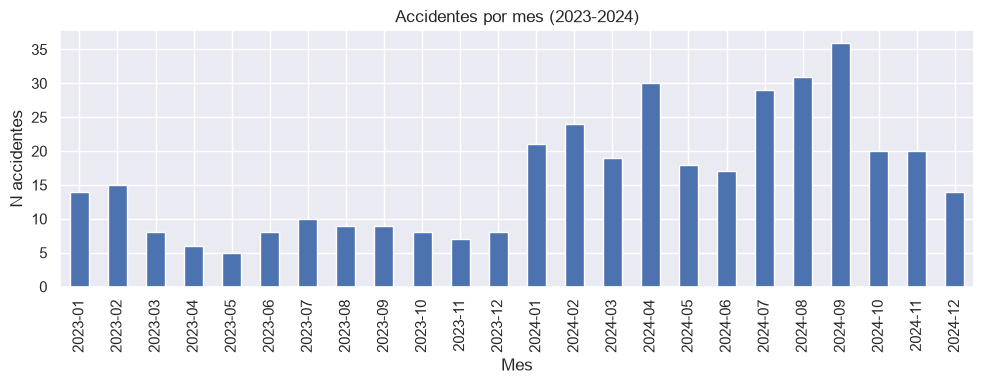

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
conteo_mes = df["fecha_evento"].dt.to_period("M").astype(str).value_counts().sort_index()
conteo_mes.plot(kind="bar", ax=ax)
ax.set_title("Accidentes por mes (2023-2024)")
ax.set_xlabel("Mes")
ax.set_ylabel("N accidentes")
fig.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "accidentes_por_mes.png", dpi=100)

## Top áreas con más accidentes

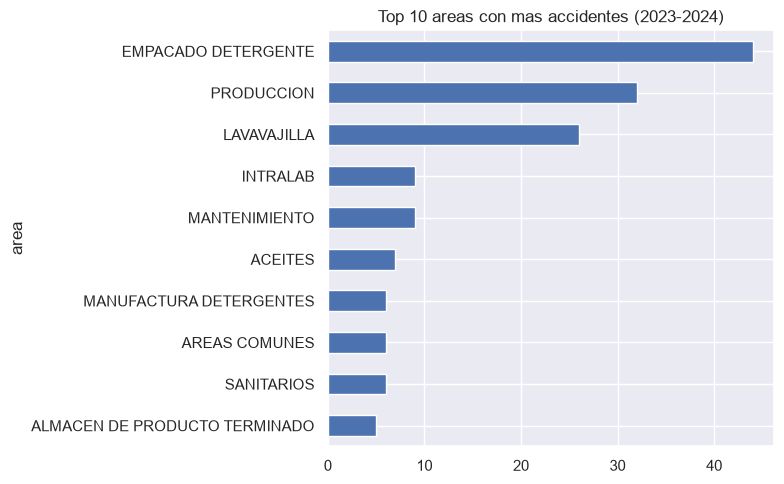

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
df["area"].value_counts().head(10).plot(kind="barh", ax=ax)
ax.set_title("Top 10 areas con mas accidentes (2023-2024)")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "top_areas_accidentes.png", dpi=100)

## Distribución por sexo

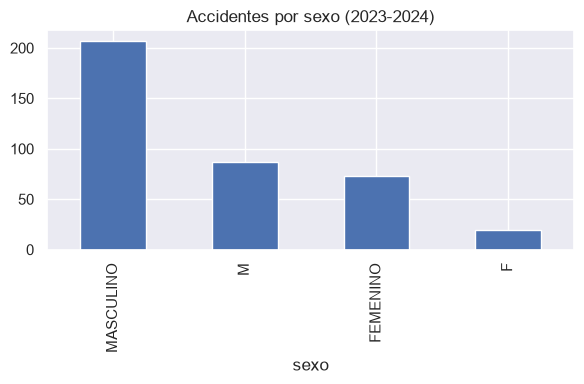

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df["sexo"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Accidentes por sexo (2023-2024)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "accidentes_por_sexo.png", dpi=100)

## Pendiente

- [ ] Cruce tipo de accidente x parte del cuerpo afectada
- [ ] Tendencia de días de descanso médico (`dias_dm`) en el tiempo
- [ ] Revisar con el equipo las columnas con >80% de nulos en cualquiera de
      los 5 CSV antes de usarlas en cualquier análisis (ver
      `reports/diccionario_datos.md`)
- [ ] EDA propio de `accidentes_historico_2012_2022.csv`,
      `accidentes_2025_2026.csv` e `incidentes_2025_2026.csv` (por ahora solo
      se ve la tendencia anual combinada arriba)
- [ ] **Antes de exportar/compartir este notebook fuera del equipo**:
      revisar que ninguna celda muestre `descripcion_accidente`,
      `descripcion_incidente` o `danos_reales_o_potenciales` sin filtrar
      (pueden contener nombres en el texto libre, no anonimizado).

Accidentes sin fecha valida (NaT, excluidos del grafico): 87

Total incidentes (evento distinto a accidente): 340


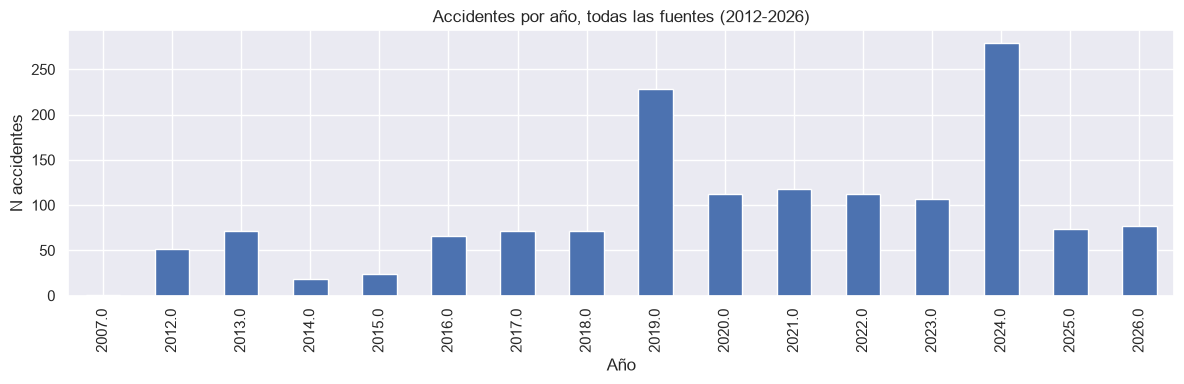

In [7]:
df_historico = pd.read_csv(PROCESSED_DIR / "accidentes_historico_2012_2022.csv",
                            parse_dates=["fecha_evento"])
df_2025_2026 = pd.read_csv(PROCESSED_DIR / "accidentes_2025_2026.csv",
                            parse_dates=["fecha_evento"])
df_incidentes = pd.read_csv(PROCESSED_DIR / "incidentes_2025_2026.csv",
                             parse_dates=["fecha_evento"])

# Solo la columna comun fecha_evento + fuente_archivo, para ver el total de
# accidentes por año a lo largo de las 4 fuentes (sin mezclar incidentes).
fechas_accidentes = pd.concat([
    df[["fecha_evento", "fuente_archivo"]],
    df_historico[["fecha_evento", "fuente_archivo"]],
    df_2025_2026[["fecha_evento", "fuente_archivo"]],
], ignore_index=True)

n_sin_fecha = fechas_accidentes["fecha_evento"].isna().sum()
print(f"Accidentes sin fecha valida (NaT, excluidos del grafico): {n_sin_fecha}")

fig, ax = plt.subplots(figsize=(12, 4))
conteo_anio = fechas_accidentes["fecha_evento"].dt.year.value_counts().sort_index()
conteo_anio.plot(kind="bar", ax=ax)
ax.set_title("Accidentes por año, todas las fuentes (2012-2026)")
ax.set_xlabel("Año")
ax.set_ylabel("N accidentes")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "accidentes_por_anio_todas_fuentes.png", dpi=100)

print()
print("Total incidentes (evento distinto a accidente):", len(df_incidentes))

## Valores atípicos (outliers)

**Política del proyecto, igual que con los nulos:** no se elimina ni se
capa ningún outlier silenciosamente. Se reportan (regla del rango
intercuartílico — IQR: atípico si cae fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`,
vía `clean.report_outliers_iqr()`) y se visualizan con boxplot. Qué hacer
con cada uno (dejarlo, caparlo, investigarlo caso a caso) es una decisión
del equipo, documentada en `reports/diccionario_datos.md` — no se decide
aquí.

In [8]:
from src.clean import report_outliers_iqr

print("--- accidentes 2023+2024 ---")
display(report_outliers_iqr(df))
print("--- accidentes_historico_2012_2022 ---")
display(report_outliers_iqr(df_historico))
print("--- accidentes_2025_2026 ---")
display(report_outliers_iqr(df_2025_2026))

--- accidentes 2023+2024 ---


,n_outliers,pct_outliers,limite_inferior,limite_superior,min,max
columna,,,,,,
dias_dm,38,10.80,-13.5,22.5,0.0,180.0
dias_dm_total_indicador,36,10.94,-12.0,20.0,0.0,904.0
tiempo_experiencia_meses,26,13.54,-103.0,177.0,0.0,348.0
anio,17,5.72,2024.0,2024.0,2023.0,2024.0


--- accidentes_historico_2012_2022 ---


,n_outliers,pct_outliers,limite_inferior,limite_superior,min,max
columna,,,,,,
dias_perdidos,107,11.75,-21.00,43.00,0.0,4500.0
dias_mas_ansi,107,11.77,-21.00,43.00,0.0,4590.0
cargo_ansi,4,16.67,-150.00,450.00,0.0,6000.0
nota_midot,3,21.43,40.38,69.38,28.0,75.0


--- accidentes_2025_2026 ---


,n_outliers,pct_outliers,limite_inferior,limite_superior,min,max
columna,,,,,,
dias_registrables,18,11.92,-19.50,40.50,1.0,1140.0
tiempo_empresa_meses,1,2.27,-201.00,399.00,1.0,456.0
tiempo_empresa_anios,1,2.33,-17.75,36.25,0.0,38.0


### Boxplot: `edad_anios` por fuente

No aparece en el reporte IQR de arriba (estadísticamente no es "atípica" en
ninguna fuente), pero igual se grafica porque es una X candidata para el
modelo (ver README sección 5) y un boxplot revela algo que el IQR no
distingue por sí solo: valores fuera de rango de negocio (ej. edad = 0, que
no es un outlier estadístico si hay pocos casos, pero sí es imposible para
un trabajador).

Filas con edad_anios <= 0 (imposible para un trabajador): 0
Series([], Name: count, dtype: int64)


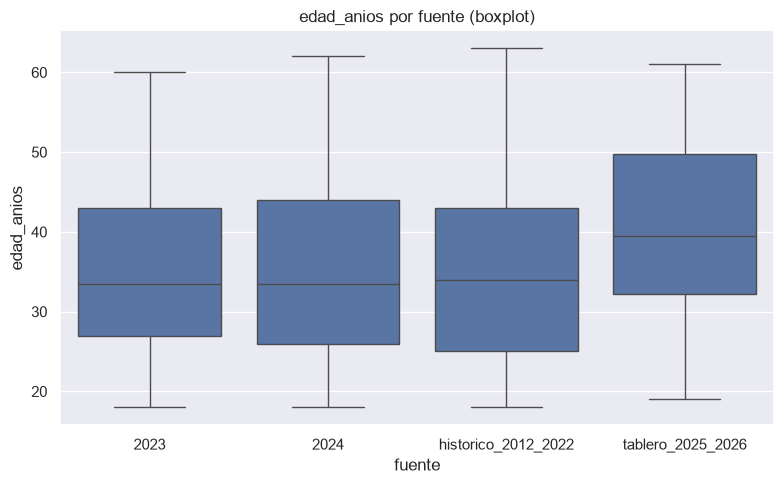

In [9]:
edad_por_fuente = pd.concat([
    df[["edad_anios", "fuente_archivo"]].assign(fuente_archivo=df["fuente_archivo"].astype(str)),
    df_historico[["edad_anios"]].assign(fuente_archivo="historico_2012_2022"),
    df_2025_2026[["edad_anios"]].assign(fuente_archivo="tablero_2025_2026"),
], ignore_index=True)

n_edad_cero_o_menos = (edad_por_fuente["edad_anios"] <= 0).sum()
print(f"Filas con edad_anios <= 0 (imposible para un trabajador): {n_edad_cero_o_menos}")
print(edad_por_fuente.loc[edad_por_fuente["edad_anios"] <= 0, "fuente_archivo"].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=edad_por_fuente, x="fuente_archivo", y="edad_anios", ax=ax)
ax.set_title("edad_anios por fuente (boxplot)")
ax.set_xlabel("fuente")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_boxplot_edad_anios.png", dpi=100)

### Boxplot: días perdidos / de descanso médico por fuente

Nombre de columna distinto por fuente (`dias_dm` en 2023/2024,
`dias_perdidos` en histórico, `dias_registrables` en 2025-2026) pero mismo
concepto. El reporte IQR de arriba ya marcó estas columnas con outliers —
el histórico tiene 3 filas en exactamente `6000` (ver celda siguiente),
un valor que se ve como tope/placeholder más que un dato real de días
perdidos.

Filas de accidentes_historico con dias_perdidos == 6000 exacto: 0


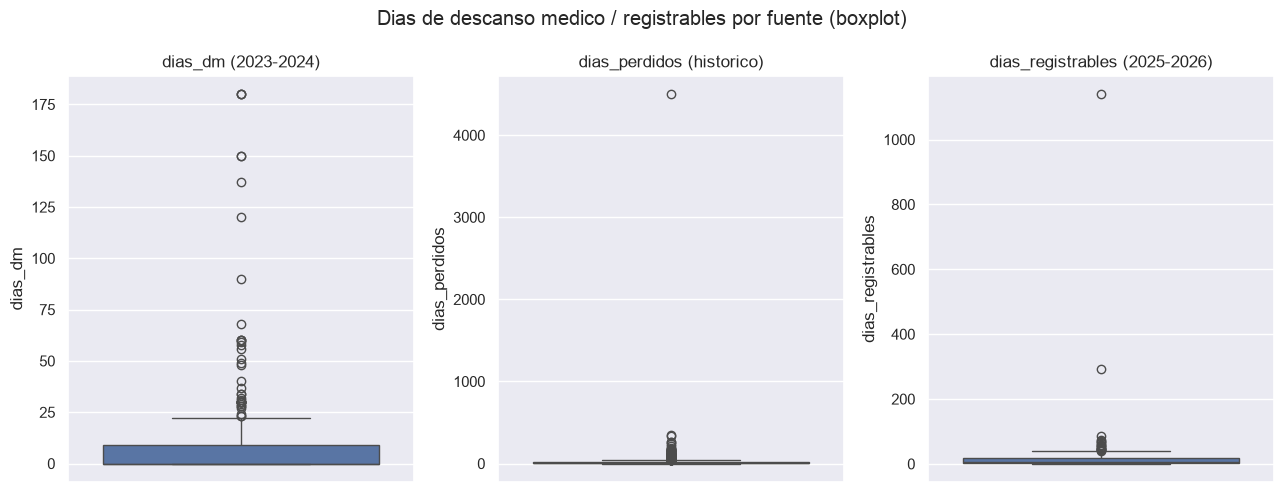

In [10]:
n_dias_6000 = (df_historico["dias_perdidos"] == 6000).sum()
print(f"Filas de accidentes_historico con dias_perdidos == 6000 exacto: {n_dias_6000}")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
sns.boxplot(y=df["dias_dm"].dropna(), ax=axes[0])
axes[0].set_title("dias_dm (2023-2024)")
sns.boxplot(y=df_historico["dias_perdidos"].dropna(), ax=axes[1])
axes[1].set_title("dias_perdidos (historico)")
sns.boxplot(y=df_2025_2026["dias_registrables"].dropna(), ax=axes[2])
axes[2].set_title("dias_registrables (2025-2026)")
fig.suptitle("Dias de descanso medico / registrables por fuente (boxplot)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_boxplot_dias_perdidos.png", dpi=100)

### Boxplot: `tiempo_experiencia_meses` (2023-2024)

El reporte IQR marcó esta columna con un máximo de 2190 meses (≈182 años),
imposible como experiencia laboral de una persona — se visualiza para
dimensionar qué tan aislado es ese valor frente al resto de la
distribución.

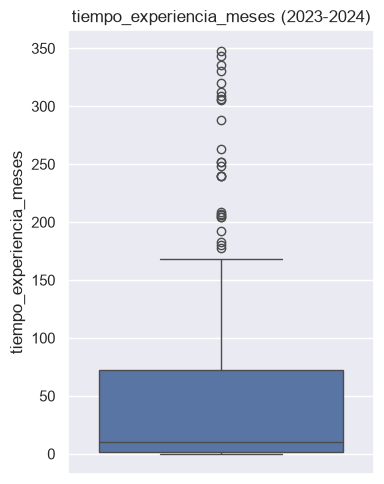

In [11]:
fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(y=df["tiempo_experiencia_meses"].dropna(), ax=ax)
ax.set_title("tiempo_experiencia_meses (2023-2024)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_boxplot_tiempo_experiencia_meses.png", dpi=100)

## Pendiente

- [ ] Cruce tipo de accidente x parte del cuerpo afectada
- [ ] Tendencia de días de descanso médico (`dias_dm`) en el tiempo
- [ ] Revisar con el equipo las columnas con >80% de nulos en 2023 antes de
      usarlas en cualquier análisis (ver `reports/diccionario_datos.md`)
- [ ] **Antes de exportar/compartir este notebook fuera del equipo**:
      revisar que ninguna celda muestre `descripcion_accidente` sin filtrar
      (puede contener nombres en el texto libre, no anonimizado).